In [1]:
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/ML-project'):
        !git clone https://github.com/14Og/ML-project-softgate-KD.git -b colab-experiments /content/ML-project
    %cd /content/ML-project

In [8]:
import sys
from pathlib import Path

root_path = Path('.').resolve()
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from src.data import load_imdb, load_20newsgroups
from src.MLP.model import MLP
from src.MLP.trainer import Trainer, KDTrainer, HKDTrainer, SKDTrainer
from src.metrics import compute_metrics, compare_metrics
from src.metrics import plot_reliability_diagram, plot_confidence_histogram, plot_training_curves

# IMDB Sentiment Classification — MLP + Knowledge Distillation

## Step 1: Load Data

In [ ]:
train_loader, test_loader, vectorizer, num_classes = load_20newsgroups(max_features=30000, ngram_range=(1, 2), batch_size=256)

input_dim = len(vectorizer.vocabulary_)
print(f"Vocabulary size: {input_dim}")

Vocabulary size: 10000


## Choosing model parameters

In [ ]:
teacher_dims = [512, 512, 256]
student_dims = [128, 64, 32]

## Step 2: Train Teacher Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")
mlp_teacher = MLP(input_dim=input_dim, hidden_dims=teacher_dims, num_classes=num_classes, dropout=0.5).to(device)
print(f"Parameters: {sum(p.numel() for p in mlp_teacher.parameters()):,}")

Using: cpu
Parameters: 5,287,316


In [ ]:
teacher_trainer = Trainer(
    model=mlp_teacher,
    optimizer=torch.optim.Adam(mlp_teacher.parameters(), lr=1e-3),
    criterion=nn.CrossEntropyLoss(),
    device=device,
)

history = teacher_trainer.fit(
    train_loader,
    test_loader,
    epochs=50,
    patience=10,
    log_every=1,
)

Epoch   1 | train loss 0.3584 acc 0.8443 | val loss 0.2885 acc 0.8768
Epoch   2 | train loss 0.2808 acc 0.8832 | val loss 0.2865 acc 0.8757
Epoch   3 | train loss 0.2541 acc 0.8969 | val loss 0.2919 acc 0.8779
Epoch   4 | train loss 0.2162 acc 0.9142 | val loss 0.2935 acc 0.8770
Epoch   5 | train loss 0.1657 acc 0.9362 | val loss 0.3576 acc 0.8693
Epoch   6 | train loss 0.1173 acc 0.9576 | val loss 0.4056 acc 0.8702
Epoch   7 | train loss 0.0855 acc 0.9695 | val loss 0.4568 acc 0.8717
Early stopping at epoch 7 (patience=5)
Restored best model (val loss 0.2865)


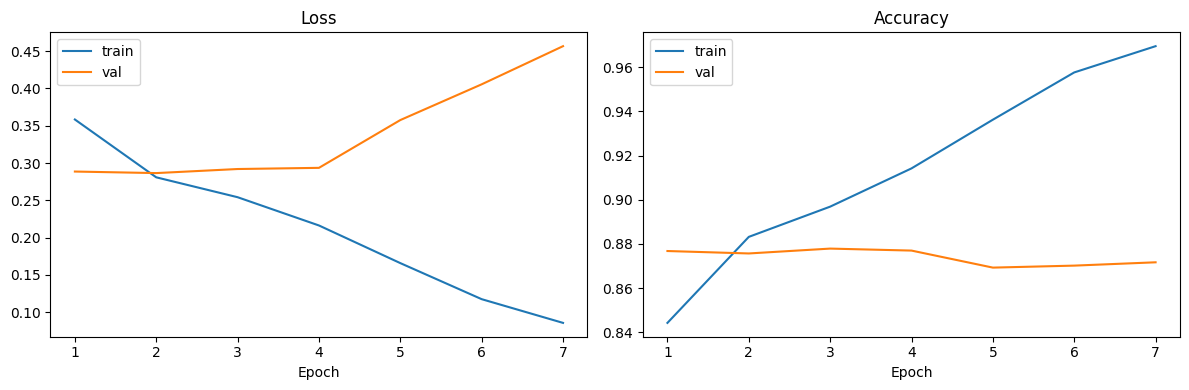

Best val accuracy: 0.8779


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history.train_loss) + 1)

ax1.plot(epochs, history.train_loss, label="train")
ax1.plot(epochs, history.val_loss, label="val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history.train_acc, label="train")
ax2.plot(epochs, history.val_acc, label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()
print(f"Best val accuracy: {history.best_val_acc:.4f}")

## Step 3: Define Student

The student is intentionally smaller than the teacher — this is the model we want to regularize well.

In [ ]:
def make_student():
    """Always create a fresh student so each variant starts from the same random init."""
    return MLP(input_dim=input_dim, hidden_dims=student_dims, num_classes=num_classes, dropout=0.3).to(device)

def make_optimizer(model):
    return torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

s = make_student()
print(f"Teacher params: {sum(p.numel() for p in mlp_teacher.parameters()):,}")
print(f"Student params: {sum(p.numel() for p in s.parameters()):,}")

Teacher params: 553,538
Student params: 130,210


## Step 4: Train All Variants

We train four student variants under identical conditions (same architecture, optimizer, early stopping).
The only difference is the training objective.

In [ ]:
fit_kwargs = dict(epochs=50, patience=10, log_every=1)

# 1. CE — plain cross-entropy, no regularization
print("=== CE ===")
student_ce = make_student()
trainer_ce = Trainer(student_ce, make_optimizer(student_ce), nn.CrossEntropyLoss(), device)
history_ce = trainer_ce.fit(train_loader, test_loader, **fit_kwargs)

=== CE ===
Epoch   5 | train loss 0.2132 acc 0.9196 | val loss 0.3087 acc 0.8764
Early stopping at epoch 7 (patience=5)
Restored best model (val loss 0.2836)


In [ ]:
# 2. LS — label smoothing (regularization baseline, no teacher needed)
print("=== Label Smoothing ===")
student_ls = make_student()
trainer_ls = Trainer(student_ls, make_optimizer(student_ls), nn.CrossEntropyLoss(label_smoothing=0.1), device)
history_ls = trainer_ls.fit(train_loader, test_loader, **fit_kwargs)

In [ ]:
# 3. KD — standard knowledge distillation with temperature
print("=== KD ===")
student_kd = make_student()
trainer_kd = KDTrainer(student_kd, mlp_teacher, make_optimizer(student_kd), device, alpha=0.5, temperature=4.0)
history_kd = trainer_kd.fit(train_loader, test_loader, **fit_kwargs)

In [ ]:
# 4. HKD — Hard Gate KD (Lee et al. 2022)
print("=== HKD ===")
student_hkd = make_student()
trainer_hkd = HKDTrainer(student_hkd, mlp_teacher, make_optimizer(student_hkd), device, temperature=4.0)
history_hkd = trainer_hkd.fit(train_loader, test_loader, **fit_kwargs)

In [ ]:
# 5. SKD — Soft Gate KD with sigmoid gate
print("=== SKD (sigmoid) ===")
student_skd = make_student()
trainer_skd = SKDTrainer(
    student_skd, mlp_teacher, make_optimizer(student_skd), device,
    temperature=4.0, gate_fn="sigmoid", sharpness=10.0,
)
history_skd = trainer_skd.fit(train_loader, test_loader, **fit_kwargs)

## Step 5: Compare Metrics

In [ ]:
# Collect predictions once per model (labels are the same for all)
teacher_logits, labels = teacher_trainer.predict(test_loader)

all_logits = {
    "Teacher":     teacher_logits,
    "Student CE":  trainer_ce.predict(test_loader)[0],
    "Student LS":  trainer_ls.predict(test_loader)[0],
    "Student KD":  trainer_kd.predict(test_loader)[0],
    "Student HKD": trainer_hkd.predict(test_loader)[0],
    "Student SKD": trainer_skd.predict(test_loader)[0],
}

results = {name: compute_metrics(logits, labels) for name, logits in all_logits.items()}
compare_metrics(results)

In [ ]:
# Reliability diagrams — one per model
fig, axes = plt.subplots(1, len(all_logits), figsize=(5 * len(all_logits), 4))
for ax, (name, logits) in zip(axes, all_logits.items()):
    plot_reliability_diagram(logits, labels, ax=ax, title=name)
plt.tight_layout()
plt.show()

In [ ]:
# Confidence histograms — one per model
fig, axes = plt.subplots(1, len(all_logits), figsize=(5 * len(all_logits), 4))
for ax, (name, logits) in zip(axes, all_logits.items()):
    plot_confidence_histogram(logits, labels, ax=ax, title=name)
plt.tight_layout()
plt.show()

In [ ]:
# Training curves — all students overlaid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for label, history in [("CE", history_ce), ("LS", history_ls), ("KD", history_kd),
                        ("HKD", history_hkd), ("SKD", history_skd)]:
    plot_training_curves(history, ax1=ax1, ax2=ax2, label=label)
plt.tight_layout()
plt.show()